In [1]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras.callbacks import EarlyStopping
from keras.layers import LSTM, Dense, Input, SimpleRNN
from keras.models import Sequential
from keras.utils import timeseries_dataset_from_array
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler


I0000 00:00:1788874889.769786   98210 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788874889.840007   98210 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788874891.193446   98210 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, usecols=[1])
dataset = df.values.astype("float32")
print(type(dataset))
print(type(df))
print(df.shape)

<class 'numpy.ndarray'>
<class 'pandas.DataFrame'>
(144, 1)


In [3]:
scaler = MinMaxScaler(feature_range=(0,1))
dataset_scaled = scaler.fit_transform(dataset)

In [4]:
type(dataset_scaled)

numpy.ndarray

In [5]:
train_size = int(len(dataset_scaled) * 0.67)
train_size

96

In [6]:
train = dataset_scaled[:train_size,:]
test = dataset_scaled[train_size:,]

In [7]:
print(train.shape)
print(test.shape)
print(train.shape[0] + test.shape[0]) # return  96 + 48 =  144

(96, 1)
(48, 1)
144


In [8]:
def create_dataset(data, look_back =2):
    X , y = [], []
    
    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back, 0])
        y.append(data[i + look_back, 0])
        
    return np.array(X), np.array(y)

look_back = 12 
    
X_train, y_train = create_dataset(train, look_back= look_back )
X_test, y_test = create_dataset(test, look_back= look_back )


In [9]:
train_dataset = timeseries_dataset_from_array(
    data = train[:-12],
    targets = train[12:],
    sequence_length = 12,
    sequence_stride = 1,
    sampling_rate = 1 ,
    shuffle = False,
    seed = 42,
    batch_size = 32
)


test_dataset = timeseries_dataset_from_array(
    data = test[:-12],
    targets = test[12:],
    sequence_length = 12,
    sequence_stride = 1,
    sampling_rate = 1,
    batch_size = 32,
    shuffle = False,
    seed = 42,
)

I0000 00:00:1788874895.670996   98210 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1765 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [10]:
X_train.shape

(84, 12)

In [11]:
X_train = X_train.reshape(X_train.shape[0], look_back, 1)
X_test = X_test.reshape(X_test.shape[0], look_back, 1)

In [12]:
y_train_original = scaler.inverse_transform(y_train.reshape(-1,1)).reshape(-1) # inverse_transform need 2-d not one d 
y_test_original = scaler.inverse_transform(y_test.reshape(-1,1)).reshape(-1)

In [13]:
rnn_model = Sequential([
    
    Input(shape=(look_back, 1)),
    
    LSTM(units=16, activation="tanh"),
    
    Dense(units=1, activation="linear")
])
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,169 (4.57 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
optimizer = keras.optimizers.Adam(learning_rate=0.01)
rnn_model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

In [15]:
earlystopping = EarlyStopping(
    monitor = "val_loss",
    mode= "min",
    verbose=1,
    patience=10,
    restore_best_weights = True
)

In [16]:
history = rnn_model.fit(
    X_train,
    y_train,
    epochs=300,
    validation_split = 0.2,
    verbose = 1,
    batch_size = 64,
    shuffle = False,
    callbacks= earlystopping
    
)

Epoch 1/300


I0000 00:00:1788874897.795205   98647 cuda_dnn.cc:461] Loaded cuDNN version 92400


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 231ms/step - loss: 0.0241 - mae: 0.1377 - val_loss: 0.0097 - val_mae: 0.0784
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0051 - mae: 0.0608 - val_loss: 0.0293 - val_mae: 0.1474
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0285 - mae: 0.1598 - val_loss: 0.0217 - val_mae: 0.1256
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0205 - mae: 0.1332 - val_loss: 0.0096 - val_mae: 0.0804
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0080 - mae: 0.0770 - val_loss: 0.0094 - val_mae: 0.0787
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0042 - mae: 0.0526 - val_loss: 0.0102 - val_mae: 0.0795
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0036 - mae: 0.0486 - val_loss: 0.0090 - val_mae: 0.0780
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0038 - mae: 0.0499 - val_loss: 0.0092 - val_mae: 0.0782
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0052 - mae: 0.0598 - va

In [17]:
y_train_original

array([115.     , 126.     , 141.     , 135.     , 125.     , 149.     ,
       170.     , 170.     , 158.     , 133.     , 114.     , 140.     ,
       145.     , 150.     , 178.     , 163.     , 172.     , 178.     ,
       199.     , 199.     , 184.     , 162.     , 146.     , 166.     ,
       171.     , 180.     , 193.     , 181.     , 183.     , 218.     ,
       230.     , 242.     , 209.     , 191.     , 172.     , 194.     ,
       196.     , 196.     , 236.     , 235.     , 229.     , 243.     ,
       264.     , 272.     , 237.     , 211.     , 180.     , 201.     ,
       204.     , 188.     , 235.     , 227.     , 234.     , 264.     ,
       302.     , 293.     , 259.     , 229.     , 203.     , 229.     ,
       242.     , 233.     , 267.     , 269.     , 270.     , 315.     ,
       363.99997, 347.     , 312.     , 274.     , 237.     , 278.     ,
       284.     , 277.     , 317.     , 313.     , 318.     , 373.99997,
       412.99997, 404.99997, 355.     , 306.     , 

In [18]:
train_predict = scaler.inverse_transform(rnn_model.predict(X_train, verbose=0).reshape(-1, 1)).reshape(-1)

In [19]:
test_predict = scaler.inverse_transform(rnn_model.predict(X_test,verbose=0).reshape(-1, 1)).reshape(-1)

In [20]:
train_rmse = np.sqrt(mean_squared_error(y_train_original,train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_original,test_predict ))

In [21]:
print(f"Train RMSE :{train_rmse:.2f}")
print(f"Test RMSE :{test_rmse:.2f}")

Train RMSE :36.29
Test RMSE :84.44


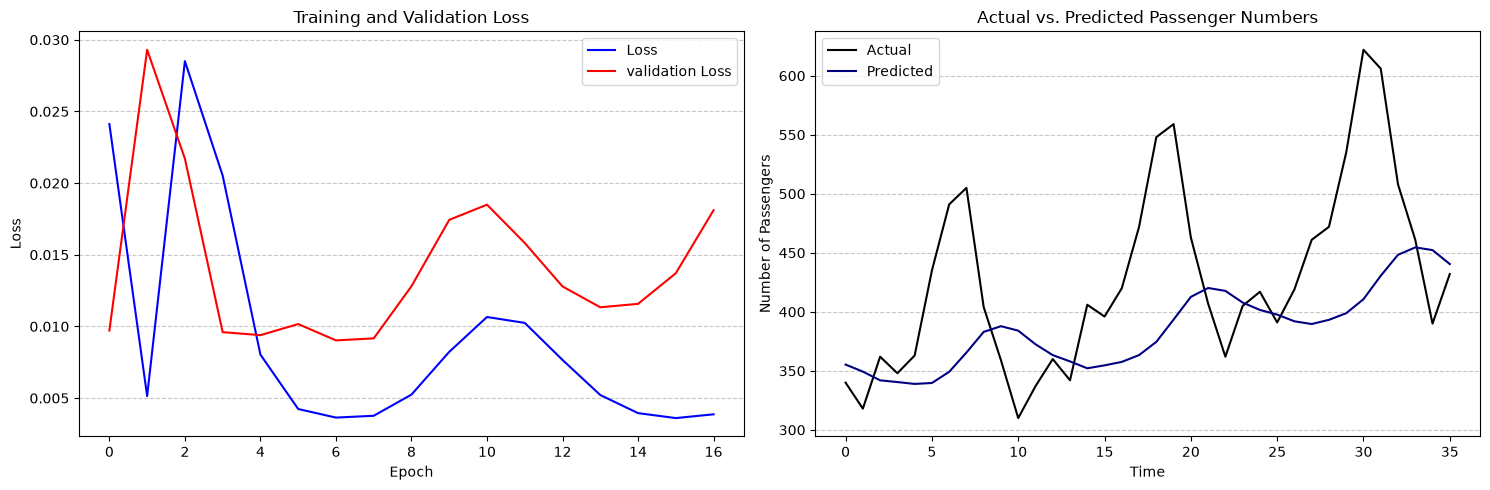

In [22]:
plt.figure(figsize=(15,5))


plt.subplot(1,2,1)
plt.plot(history.history["loss"], color="blue", label = "Loss")
plt.plot(history.history["val_loss"], color="red", label = "validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.grid(True, axis="y", alpha = 0.7, linestyle= "--")
plt.legend()

plt.subplot(1,2,2)

plt.plot(y_test_original  ,label = "Actual", color="black")
plt.plot(test_predict ,label="Predicted", color= "navy")
plt.title("Actual vs. Predicted Passenger Numbers")
plt.xlabel("Time")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.legend()
plt.grid(True, axis="y", alpha = 0.7, linestyle= "--")
plt.show()